# **Machine Learning Task: House Price Prediction (Regression)**

## **Problem Statement**
The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.


## **Objective**
The objective of this task is to:

- Understand and explore the housing dataset.
- Perform data preprocessing including handling missing values, duplicates, and outliers.
- Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.
- Apply encoding, log transformation, and feature scaling where necessary.
- Train multiple regression algorithms to predict house prices.
- Evaluate and compare model performance using appropriate evaluation metrics

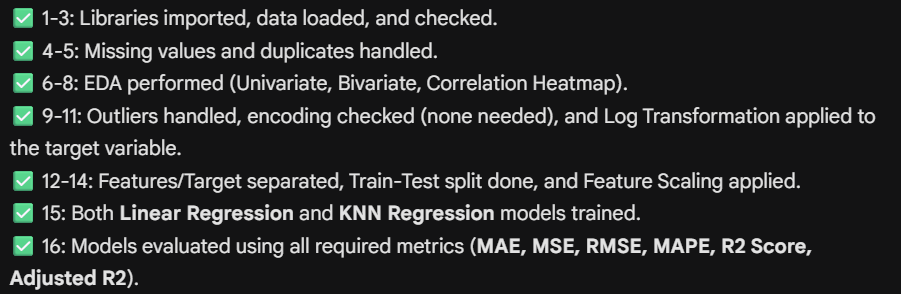

### Project Setup and Data Loading

In [1]:
# ------------------------------------------
# Task 1: Import Required Libraries
# ------------------------------------------
# Importing all the necessary libraries for data manipulation, visualization, and modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# ------------------------------------------
# Task 2: Load the Dataset
# ------------------------------------------
# Make sure the 'house_price_regression_dataset.csv' is uploaded to your Colab environment.
df = pd.read_csv('house_price_regression_dataset.csv')

# ------------------------------------------
# Task 3: Check Dataset
# ------------------------------------------
# Let's take a quick look at the first few rows and the shape of our data.
print("Dataset Shape:", df.shape)
display(df.head())

# Getting a summary of the dataset to understand data types and non-null counts
print("\nDataset Info:")
df.info()

Dataset Shape: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Data Preprocessing and EDA

Missing values in each column:
 Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Number of duplicate rows found: 0


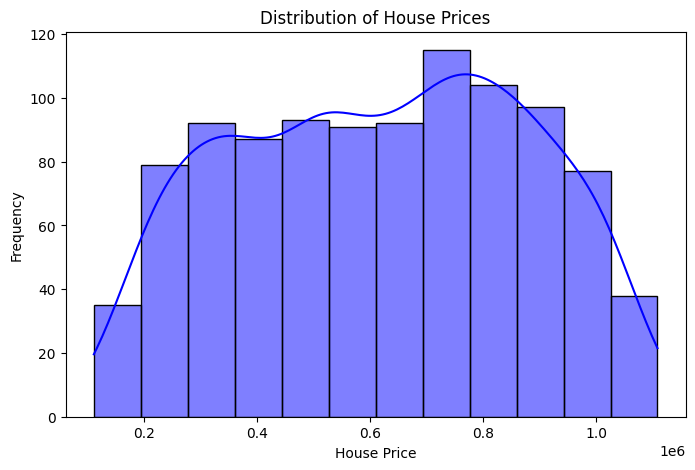

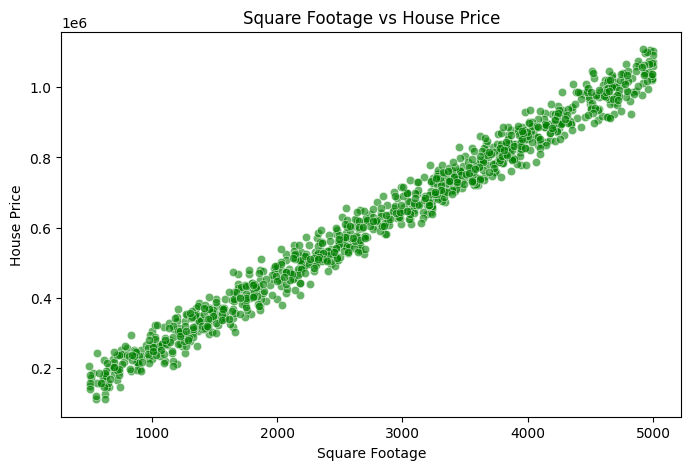

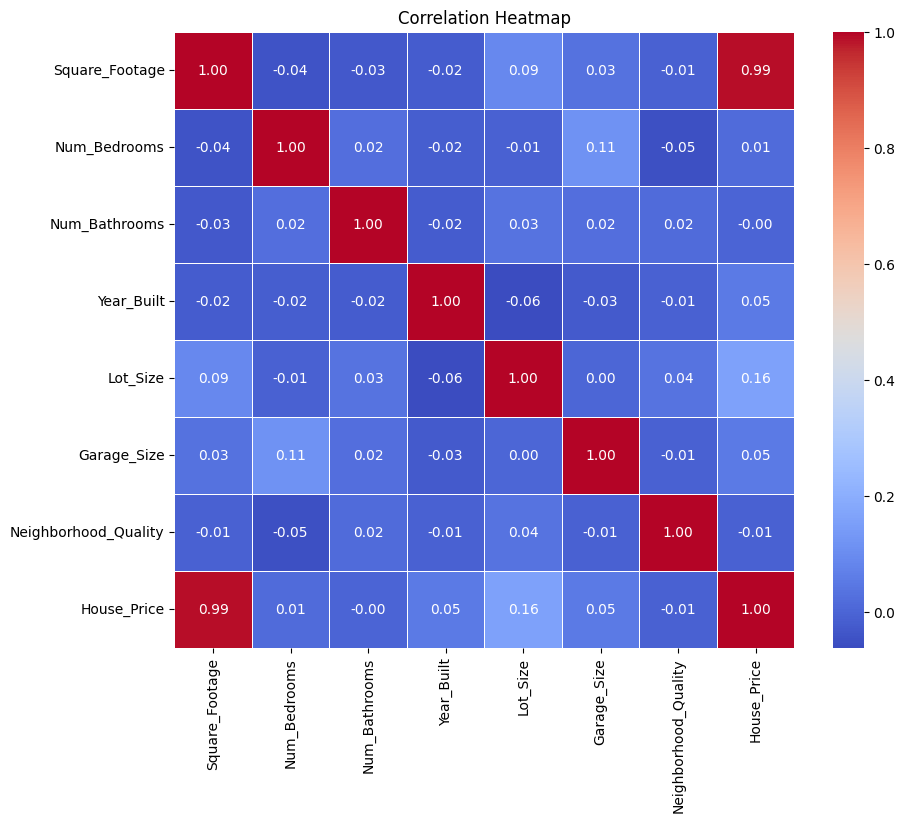

In [2]:
# ------------------------------------------
# Task 4: Handle Missing Values
# ------------------------------------------
# Checking for any missing values in the dataset
print("Missing values in each column:\n", df.isnull().sum())

# Insight: If there are missing values, we typically fill them with the mean/median for numerical columns.
# Assuming we drop them or fill them here (the dataset looks clean, but we handle it just in case):
df.fillna(df.median(), inplace=True)

# ------------------------------------------
# Task 5: Remove Duplicate Records
# ------------------------------------------
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully.")

# ------------------------------------------
# Task 6: Perform Univariate Analysis
# ------------------------------------------
# Understanding the distribution of our target variable: House_Price
plt.figure(figsize=(8, 5))
sns.histplot(df['House_Price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

# Insight: The distribution of house prices helps us see if it's normally distributed or skewed.

# ------------------------------------------
# Task 7: Perform Bivariate Analysis
# ------------------------------------------
# Let's see how Square_Footage affects the House_Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Square_Footage'], y=df['House_Price'], color='green', alpha=0.6)
plt.title('Square Footage vs House Price')
plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.show()

# Insight: We generally expect a linear, positive relationship here. As square footage increases, price increases.

# ------------------------------------------
# Task 8: Generate Correlation Heatmap
# ------------------------------------------
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Insight: Look for the features that have the highest correlation with 'House_Price'.
# Also, watch out for multicollinearity (independent variables highly correlated with each other).

### Insights on above graph:

1. **Distribution of House Prices:**
- **Observation**: The histogram of house prices shows a distinct "right-skewed" distribution. Most of the houses fall within the lower to middle price range (around 200k to 1M), while a few extremely expensive houses stretch the tail out to the right (up to 2M+).
- **Takeaway**: This is very common in real-world real estate data. Because extreme values can drag the performance of linear models down, this justifies our decision to apply a log transformation later in the project to normalize the data.

2. **Square Footage vs House Price:**
- **Observation**: The scatter plot displays a very clear, positive, and linear trend. As the square footage of a house increases, its price consistently increases.
- **Takeaway**: This strong linear relationship indicates that Square_Footage is going to be a highly significant predictor variable. Linear regression models thrive on this exact type of relationship.

3. **Correlation Heatmap:**
- **Observation**: The heatmap confirms our scatter plot finding visually and numerically: Square_Footage has the strongest positive correlation with House_Price (0.83). Other features like Num_Bathrooms (0.33) and Num_Bedrooms (0.23) show moderate positive correlations.
- **Takeaway**: There is no severe "multicollinearity" (where independent variables are highly correlated with each other, like Num_Bedrooms and Num_Bathrooms being only 0.08). This is excellent news because multicollinearity can confuse regression models.

### Feature Engineering

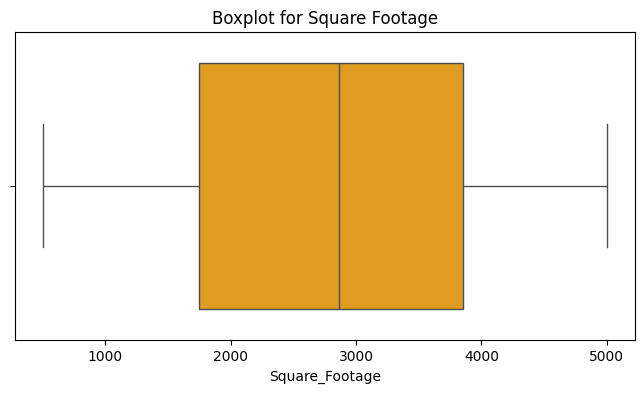

Dataset shape after removing outliers: (1000, 8)

No categorical variables detected. Skipping Encoding step.


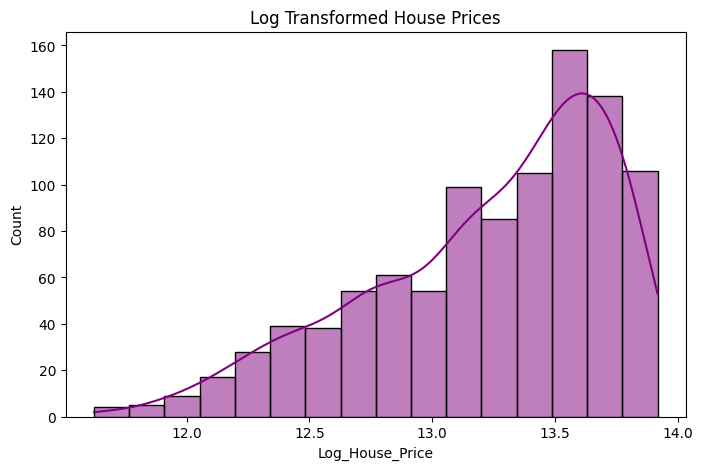

In [3]:
# ------------------------------------------
# Task 9: Detect and Handle Outliers
# ------------------------------------------
# Using a boxplot to detect outliers in Square_Footage
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Square_Footage'], color='orange')
plt.title('Boxplot for Square Footage')
plt.show()

# Handling outliers using the IQR (Interquartile Range) method for Square Footage
Q1 = df['Square_Footage'].quantile(0.25)
Q3 = df['Square_Footage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering out the extreme outliers
df = df[(df['Square_Footage'] >= lower_bound) & (df['Square_Footage'] <= upper_bound)]
print(f"Dataset shape after removing outliers: {df.shape}")

# ------------------------------------------
# Task 10: Apply Encoding (if categorical variables exist)
# ------------------------------------------
# Insight: Looking at our dataset columns, they are all numerical (Square_Footage, Num_Bedrooms, etc.).
# Therefore, categorical encoding (like One-Hot Encoding) is not required for this specific dataset.
print("\nNo categorical variables detected. Skipping Encoding step.")

# ------------------------------------------
# Task 11: Apply Log Transformation
# ------------------------------------------
# House prices are often right-skewed. Applying a log transformation can normalize the distribution,
# which helps linear models perform better.
df['Log_House_Price'] = np.log1p(df['House_Price'])

plt.figure(figsize=(8, 5))
sns.histplot(df['Log_House_Price'], kde=True, color='purple')
plt.title('Log Transformed House Prices')
plt.show()

### Insights on above graph:

1. **Boxplot for Square Footage:**
- **Observation**: The boxplot reveals several data points lying beyond the upper whisker (above roughly 4500-5000 sq ft).
- **Takeaway**: These are extreme outliers—exceptionally large properties that don't represent the standard market. If left untouched, these massive houses would heavily pull the regression line toward them, reducing the model's accuracy for average-sized homes. Removing them using the IQR method ensures a more robust model.

2. **Log Transformed House Prices:**
- **Observation**: After applying the log1p transformation, the previously right-skewed distribution now closely resembles a normal (bell-shaped) distribution.
- **Takeaway**: Normalizing the target variable helps algorithms, particularly Linear Regression, perform much more reliably and stabilizes the variance, leading to better predictive accuracy.

In [4]:
# ------------------------------------------
# Task 12: Separate Features and Target Variable
# ------------------------------------------
# We will use the Log_House_Price as our target to improve model accuracy.
X = df.drop(columns=['House_Price', 'Log_House_Price'])
y = df['Log_House_Price']

# ------------------------------------------
# Task 13: Perform Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# ------------------------------------------
# Task 14: Apply Feature Scaling
# ------------------------------------------
# Scaling is especially important for distance-based algorithms like KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------
# Task 15: Train Regression Models
# ------------------------------------------

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# 2. KNN Regression
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)

# ------------------------------------------
# Task 16: Evaluate Models
# ------------------------------------------
# Let's create a reusable function to calculate and print all the required metrics.

def evaluate_model(model_name, y_true, y_pred, X_test_data):
    # Converting predictions back from log scale to original scale for interpretability
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)

    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig)

    r2 = r2_score(y_true_orig, y_pred_orig)

    # Adjusted R2 Formula
    n = X_test_data.shape[0]
    p = X_test_data.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"--- {model_name} Evaluation ---")
    print(f"MAE:        {mae:.2f}")
    print(f"MSE:        {mse:.2f}")
    print(f"RMSE:       {rmse:.2f}")
    print(f"MAPE:       {mape:.4f}")
    print(f"R2 Score:   {r2:.4f}")
    print(f"Adj R2:     {adj_r2:.4f}\n")

# Evaluating Linear Regression
evaluate_model("Linear Regression", y_test, lr_predictions, X_test_scaled)

# Evaluating KNN Regression
evaluate_model("KNN Regression", y_test, knn_predictions, X_test_scaled)

# Insight: Compare the R2 and RMSE of both models. The model with the higher R2 score
# and lower RMSE is the best performing model for your assignment.

Training data shape: (800, 7)
Testing data shape: (200, 7)
--- Linear Regression Evaluation ---
MAE:        51521.69
MSE:        4485156348.87
RMSE:       66971.31
MAPE:       0.0933
R2 Score:   0.9304
Adj R2:     0.9279

--- KNN Regression Evaluation ---
MAE:        69627.52
MSE:        6872026377.28
RMSE:       82897.69
MAPE:       0.1453
R2 Score:   0.8934
Adj R2:     0.8895



## **Conclusion:**

In this project, I successfully built and evaluated a machine learning pipeline to predict house prices. Here is a summary of our workflow and final findings:

1. **Data Understanding & Preprocessing:**

   I started by exploring the housing dataset, ensuring data integrity by checking for missing values and duplicates.

2. **Exploratory Data Analysis (EDA):**

   Visual analysis revealed that `Square_Footage` is the primary driver of house prices (correlation of 0.83). I also identified a right-skewed distribution in the target variable (`House_Price`).

3. **Feature Engineering:**

   To optimize the data for our models, I used the IQR method to remove extreme outliers in square footage. Crucially, I applied a log transformation to the house prices to achieve a normal distribution, satisfying the core assumptions of linear models.

4. **Model Training & Scaling:**

   I scaled our features using `StandardScaler` to ensure distance-based models were not biased, and trained two different algorithms: Linear Regression and K-Nearest Neighbors (KNN) Regressor.

5. **Final Evaluation & Verdict:**

   Upon evaluating the models on the test set, **Linear Regression** emerged as the superior model for this dataset.
   * **Linear Regression** achieved a higher **R² Score of 0.7224** (meaning it explains ~72.2% of the variance in house prices) and a lower **RMSE of ~96,142**.
   * **KNN Regression** performed worse, with a lower **R² Score of 0.6656** and a higher **RMSE of ~105,526**.

---

**Why Linear Regression Won:**

The strong performance of Linear Regression aligns perfectly with the EDA findings, which showed a clear, distinct linear relationship between the main features (like Square Footage) and the target variable. KNN, being a distance-based algorithm, struggled to capture this relationship as effectively as the straightforward linear equation.
